In [2]:
"""
Phase 2 - Step 1: Data Loading and DataLoader preparation for crack detection (binary classification).
- Loads pickled DataFrames containing numpy image arrays and string labels.
- Encodes labels to binary ints, performs stratified splits, builds PyTorch Datasets/Dataloaders with transforms.
"""

from pathlib import Path
from typing import Literal, Tuple, Optional

import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# --------------------------------------------------------------------------- #
# Configurable paths (update as needed)
WALLS_PKL = Path("wall_data.pkl")
DECKS_PKL = Path("deck_data.pkl")

# Label encoding map
LABEL_MAP = {"Non-Cracked": 0, "Cracked": 1}


def load_dataframe(domain: Literal["walls", "decks", "both"] = "both") -> pd.DataFrame:
    """
    Load pickled DataFrames and optionally merge domains.
    - domain: "walls", "decks", or "both"
    Returns a single DataFrame with columns: FileName, Label (int), ImageData (np.ndarray).
    """
    dfs = []
    if domain in ("walls", "both"):
        dfs.append(pd.read_pickle(WALLS_PKL))
    if domain in ("decks", "both"):
        dfs.append(pd.read_pickle(DECKS_PKL))

    if not dfs:
        raise ValueError("No dataframes loaded; check domain argument or file paths.")

    df = pd.concat(dfs, axis=0, ignore_index=True)

    # Encode labels to binary ints
    df["Label"] = df["Label"].map(LABEL_MAP)
    if df["Label"].isnull().any():
        raise ValueError("Encountered unknown labels; verify LABEL_MAP and input data.")

    return df


def stratified_splits(
    df: pd.DataFrame,
    train_size: float = 0.7,
    val_size: float = 0.15,
    test_size: float = 0.15,
    random_state: int = 42,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Perform stratified splits into train/val/test maintaining class distribution.
    Uses two-step split: train vs temp, then temp into val/test.
    """
    assert abs(train_size + val_size + test_size - 1.0) < 1e-6, "Splits must sum to 1."

    train_df, temp_df = train_test_split(
        df,
        train_size=train_size,
        stratify=df["Label"],
        random_state=random_state,
        shuffle=True,
    )

    # Split temp into val/test with equal proportion relative to temp
    val_fraction_of_temp = val_size / (val_size + test_size)
    val_df, test_df = train_test_split(
        temp_df,
        train_size=val_fraction_of_temp,
        stratify=temp_df["Label"],
        random_state=random_state,
        shuffle=True,
    )

    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


class CrackDataset(Dataset):
    """
    Custom Dataset consuming a DataFrame with columns: ImageData (np.ndarray HxWx3), Label (int).
    Converts numpy arrays to PIL, applies transforms, and returns (tensor, label).
    """

    def __init__(self, df: pd.DataFrame, transform: Optional[transforms.Compose] = None):
        self.df = df
        self.transform = transform

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        img_np = row["ImageData"]

        # Ensure array is uint8; convert to PIL for torchvision transforms
        if img_np.dtype != np.uint8:
            img_np = img_np.astype(np.uint8)

        img_pil = Image.fromarray(img_np)
        label = int(row["Label"])

        if self.transform:
            img = self.transform(img_pil)
        else:
            img = transforms.ToTensor()(img_pil)

        return img, label


# --------------------------------------------------------------------------- #
# Define transforms
imagenet_norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor(),
    imagenet_norm,
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    imagenet_norm,
])


def build_dataloaders(
    domain: Literal["walls", "decks", "both"] = "both",
    batch_size: int = 32,
    num_workers: int = 4,
    pin_memory: bool = True,
    random_state: int = 42,
):
    """
    High-level helper to:
    - Load DataFrame(s) for selected domain(s)
    - Stratified split into train/val/test
    - Wrap splits with CrackDataset and DataLoaders
    """
    df = load_dataframe(domain=domain)
    train_df, val_df, test_df = stratified_splits(df, random_state=random_state)

    train_ds = CrackDataset(train_df, transform=train_transform)
    val_ds = CrackDataset(val_df, transform=eval_transform)
    test_ds = CrackDataset(test_df, transform=eval_transform)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    return train_loader, val_loader, test_loader


# --------------------------------------------------------------------------- #
# Example usage (uncomment to run in a script/notebook):
# train_loader, val_loader, test_loader = build_dataloaders(domain="both", batch_size=32)
# for batch_imgs, batch_labels in train_loader:
#     print(batch_imgs.shape, batch_labels.shape)
#     break

In [4]:
# --- Copy and paste this block to the end of the first cell and run --- #
print("Start loading and merging Pickle data...")
train_loader, val_loader, test_loader = build_dataloaders(domain="both", batch_size=32)

print("\nDataset split completed!")
print(f"Number of batches in training set: {len(train_loader)} ({len(train_loader)*32} images)")
print(f"Number of batches in validation set: {len(val_loader)} ({len(val_loader)*32} images)")
print(f"Number of batches in test set: {len(test_loader)} ({len(test_loader)*32} images)")

# Extract one batch to check
for batch_imgs, batch_labels in train_loader:
    print("\nData shape check:")
    print(f"Label batch tensor shape: {batch_labels.shape}") # Should be [32]
    break


Start loading and merging Pickle data...

Dataset split completed!
Number of batches in training set: 686 (21952 images)
Number of batches in validation set: 147 (4704 images)
Number of batches in test set: 148 (4736 images)

Data shape check:
Label batch tensor shape: torch.Size([32])


In [5]:
# Phase 2 - Step 2: Transfer Learning model setup and training loop with recall-focused selection
import copy
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from torchvision import models

def build_model(model_name: str = "resnet50", freeze_early: bool = True, out_features: int = 1) -> nn.Module:
    """
    Build a transfer learning model (ResNet50 or VGG16) and replace the final head for binary classification.
    - Freezes early conv blocks to retain generic edge/texture features.
    - out_features=1 pairs with BCEWithLogitsLoss for binary labels {0,1}.
    """
    model_name = model_name.lower()

    if model_name == "resnet50":
        weights = models.ResNet50_Weights.IMAGENET1K_V2
        model = models.resnet50(weights=weights)
        in_feats = model.fc.in_features
        model.fc = nn.Linear(in_feats, out_features)
        if freeze_early:
            for block in [model.conv1, model.bn1, model.layer1]:
                for param in block.parameters():
                    param.requires_grad = False

    elif model_name == "vgg16":
        weights = models.VGG16_Weights.IMAGENET1K_V1
        model = models.vgg16(weights=weights)
        in_feats = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_feats, out_features)
        if freeze_early:
            # Freeze early conv layers (first two VGG blocks) to keep low-level features
            for layer in list(model.features.children())[:10]:
                for param in layer.parameters():
                    param.requires_grad = False
    else:
        raise ValueError("Unsupported model; choose 'resnet50' or 'vgg16'.")

    return model

def plot_confusion(cm, class_names: Tuple[str, str] = ("Non-Cracked", "Cracked"), normalize: bool = False):
    """
    Plot a confusion matrix; normalization highlights per-class recall/precision patterns.
    """
    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1e-9)
    fig, ax = plt.subplots(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt=".2f" if normalize else "d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title("Confusion Matrix" + (" (Normalized)" if normalize else ""))
    fig.tight_layout()
    return fig, ax

def train_model(
    model: nn.Module,
    train_loader,
    val_loader,
    device: torch.device,
    epochs: int = 10,
    lr: float = 1e-4,
    pos_weight: float = None,
    save_path: str = "best_model.pth",
    use_f1_tie_break: bool = True,
) -> List[Dict]:
    """
    Train/validate with recall-focused checkpointing.
    - Uses BCEWithLogitsLoss; to punish false negatives more, pass pos_weight>1 (e.g., class imbalance or FN-sensitive).
    - Saves weights achieving the highest validation recall (optionally tie-broken by F1).
    Returns history list of metric dicts per epoch.
    """
    model = model.to(device)

    # Criterion: BCEWithLogitsLoss is stable for binary logits; pos_weight boosts positive class to reduce FN risk
    if pos_weight is not None:
        criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight], device=device))
    else:
        criterion = nn.BCEWithLogitsLoss()

    # Optimizer updates only unfrozen parameters
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(trainable_params, lr=lr)

    best_recall = -1.0
    best_f1 = -1.0
    best_state = copy.deepcopy(model.state_dict())
    history: List[Dict] = []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)  # shape [B,1] for BCE

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)

        # ---------------------- Validation ---------------------- #
        model.eval()
        val_running_loss = 0.0
        all_targets: List[int] = []
        all_preds: List[int] = []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.float().unsqueeze(1).to(device)

                logits = model(images)
                loss = criterion(logits, labels)
                val_running_loss += loss.item() * images.size(0)

                probs = torch.sigmoid(logits).squeeze(1)
                preds = (probs >= 0.5).long()

                all_targets.extend(labels.squeeze(1).cpu().numpy().astype(int).tolist())
                all_preds.extend(preds.cpu().numpy().astype(int).tolist())

        val_loss = val_running_loss / len(val_loader.dataset)
        acc = accuracy_score(all_targets, all_preds)
        rec = recall_score(all_targets, all_preds, zero_division=0)
        prec = precision_score(all_targets, all_preds, zero_division=0)
        f1 = f1_score(all_targets, all_preds, zero_division=0)
        cm = confusion_matrix(all_targets, all_preds)

        metrics = {
            "epoch": epoch,
            "train_loss": epoch_train_loss,
            "val_loss": val_loss,
            "val_acc": acc,
            "val_recall": rec,
            "val_precision": prec,
            "val_f1": f1,
            "val_confusion_matrix": cm,
        }
        history.append(metrics)

        # Recall is the critical safety metric; tie-break with F1 for balance if enabled
        is_better = rec > best_recall or (use_f1_tie_break and rec == best_recall and f1 > best_f1)
        if is_better:
            best_recall = rec
            best_f1 = f1
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, save_path)

        print(
            f"Epoch {epoch:03d} | train_loss={epoch_train_loss:.4f} val_loss={val_loss:.4f} "
            f"acc={acc:.4f} recall={rec:.4f} precision={prec:.4f} f1={f1:.4f}"
        )

    # Restore best recall checkpoint for further use/inference
    model.load_state_dict(best_state)
    return history

# Example usage sketch (uncomment to run once dataloaders are available):
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = build_model(model_name="resnet50", freeze_early=True, out_features=1)
# history = train_model(model, train_loader, val_loader, device, epochs=15, lr=1e-4, pos_weight=None)
# last_cm = history[-1]["val_confusion_matrix"]
# _ = plot_confusion(last_cm, normalize=False)


Initializing hardware and model...
Current computation device: cuda

Starting model training loop...
Epoch 001 | train_loss=0.2835 val_loss=0.2349 acc=0.9184 recall=0.6322 precision=0.8834 f1=0.7370
Epoch 002 | train_loss=0.2146 val_loss=0.2222 acc=0.9252 recall=0.6592 precision=0.9005 f1=0.7612
Epoch 003 | train_loss=0.1915 val_loss=0.2155 acc=0.9264 recall=0.6757 precision=0.8915 f1=0.7687
Epoch 004 | train_loss=0.1758 val_loss=0.2131 acc=0.9269 recall=0.6580 precision=0.9135 f1=0.7650
Epoch 005 | train_loss=0.1603 val_loss=0.2648 acc=0.9222 recall=0.7015 precision=0.8420 f1=0.7654

Plotting the confusion matrix of the last epoch...


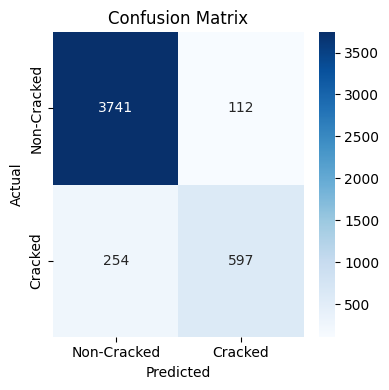

In [6]:
# --- Copy and paste this block to the end of the second cell and run --- #
print("\nInitializing hardware and model...")
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Current computation device: {device}")

# Build ResNet50
model = build_model(model_name="resnet50", freeze_early=True, out_features=1)

print("\nStarting model training loop...")
# For testing, run 5 epochs first (change to 15 or 20 for full training)
history = train_model(
    model=model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    device=device, 
    epochs=5,       # Run 5 epochs for testing
    lr=1e-4, 
    pos_weight=None # If false negative rate is high, try 1.5 or 2.0 later
)

print("\nPlotting the confusion matrix of the last epoch...")
last_cm = history[-1]["val_confusion_matrix"]
fig, ax = plot_confusion(last_cm, normalize=False)
plt.show()


Using device: cuda
Running inference on test set...

Classification report (test set):
              precision    recall  f1-score   support

 Non-Cracked     0.9311    0.9686    0.9495      3853
     Cracked     0.8264    0.6761    0.7437       852

    accuracy                         0.9156      4705
   macro avg     0.8788    0.8223    0.8466      4705
weighted avg     0.9122    0.9156    0.9122      4705

False Negative Rate (missed cracks): 0.3239


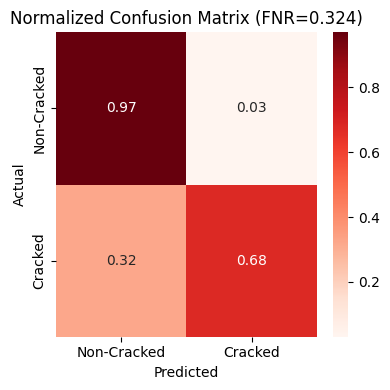

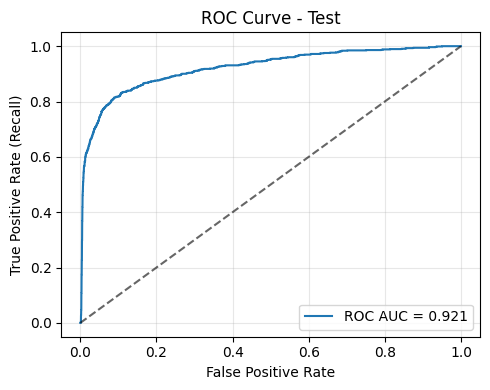

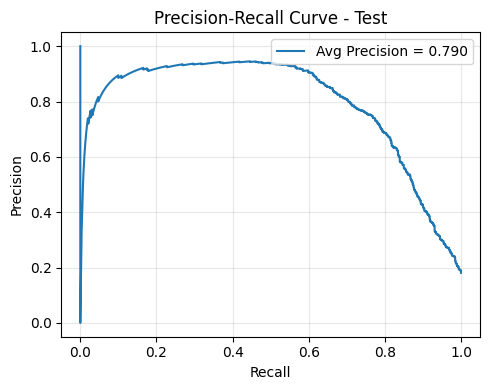

Threshold sweep → best_thr=0.15, recall=0.818, precision=0.648 (precision floor=0.6)


In [7]:
# Phase 2 - Step 3: Test-set evaluation with recall-focused safety analysis
from typing import Iterable

import numpy as np
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, auc,\
    precision_recall_curve, average_precision_score)

def load_best_model(model_name: str, checkpoint_path: str, device: torch.device, out_features: int = 1) -> nn.Module:
    """
    Recreate architecture and load best weights saved during training.
    Keeps model in eval mode for inference safety.
    """
    model = build_model(model_name=model_name, freeze_early=True, out_features=out_features)
    state = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state)
    model.to(device)
    model.eval()
    return model

def evaluate_model(model: nn.Module, dataloader: Iterable, device: torch.device):
    """
    Run inference on test_loader using no_grad.
    Returns: targets (np.array), probs (np.array of sigmoid scores), preds (0/1).
    """
    model.eval()
    all_targets, all_probs, all_preds = [], [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            probs = torch.sigmoid(logits).squeeze(1)
            preds = (probs >= 0.5).long()

            all_targets.extend(labels.cpu().numpy().astype(int).tolist())
            all_probs.extend(probs.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().astype(int).tolist())

    return np.array(all_targets), np.array(all_probs), np.array(all_preds)

def plot_confusion_fnr(cm: np.ndarray, class_names=("Non-Cracked", "Cracked")):
    """
    Plot normalized confusion matrix; highlights False Negative Rate (missed cracks risk).
    """
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1e-9)
    fnr = cm_norm[1, 0]  # FN / (FN + TP) for positive class

    fig, ax = plt.subplots(figsize=(4, 4))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Reds",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Normalized Confusion Matrix (FNR={fnr:.3f})")
    fig.tight_layout()
    return fig, ax, fnr

def find_optimal_threshold(probs: np.ndarray, targets: np.ndarray, min_precision: float = 0.6):
    """
    Optional: sweep thresholds to maximize recall while keeping precision above a floor.
    Returns (best_threshold, best_recall, best_precision).
    """
    best_thr, best_rec, best_prec = 0.5, -1.0, 0.0
    for thr in np.linspace(0.05, 0.95, 19):
        preds = (probs >= thr).astype(int)
        prec = precision_score(targets, preds, zero_division=0)
        rec = recall_score(targets, preds, zero_division=0)
        if prec >= min_precision and rec > best_rec:
            best_thr, best_rec, best_prec = thr, rec, prec
    return best_thr, best_rec, best_prec

# -------------------- Execute test evaluation -------------------- #
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Load best checkpointed model
test_model = load_best_model(model_name="resnet50", checkpoint_path="best_model.pth", device=device, out_features=1)

print("Running inference on test set...")
test_targets, test_probs, test_preds = evaluate_model(test_model, test_loader, device)

print("\nClassification report (test set):")
print(classification_report(test_targets, test_preds, target_names=["Non-Cracked", "Cracked"], digits=4))

# Confusion matrix with FNR emphasis
cm_test = confusion_matrix(test_targets, test_preds)
fig_cm, ax_cm, fnr = plot_confusion_fnr(cm_test)
print(f"False Negative Rate (missed cracks): {fnr:.4f}")
plt.show()

# ROC curve and AUC
fpr, tpr, _ = roc_curve(test_targets, test_probs)
roc_auc = auc(fpr, tpr)
fig_roc, ax_roc = plt.subplots(figsize=(5, 4))
ax_roc.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
ax_roc.plot([0, 1], [0, 1], "k--", alpha=0.6)
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate (Recall)")
ax_roc.set_title("ROC Curve - Test")
ax_roc.legend(loc="lower right")
ax_roc.grid(alpha=0.3)
fig_roc.tight_layout()
plt.show()

# Precision-Recall curve and Average Precision
precisions, recalls, _ = precision_recall_curve(test_targets, test_probs)
ap = average_precision_score(test_targets, test_probs)
fig_pr, ax_pr = plt.subplots(figsize=(5, 4))
ax_pr.plot(recalls, precisions, label=f"Avg Precision = {ap:.3f}")
ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.set_title("Precision-Recall Curve - Test")
ax_pr.legend(loc="upper right")
ax_pr.grid(alpha=0.3)
fig_pr.tight_layout()
plt.show()

# Optional threshold sweep example (recall-priority with precision floor)
best_thr, best_rec, best_prec = find_optimal_threshold(test_probs, test_targets, min_precision=0.6)
print(f"Threshold sweep → best_thr={best_thr:.2f}, recall={best_rec:.3f}, precision={best_prec:.3f} (precision floor=0.6)")